# SKA-low mock signals: priors

Self-contained version of the SKA section of `test_corrfield.ipynb` with priors tuned to the simulated SKA-low pulse. Cells can be pasted into that notebook's SKA section (they replace the `t800`, `Cov`, `cf_kwargs`/`my_model` and mock-drawing cells).

**SKA-low model (differs from LOFAR on purpose)**

signal(t) = BandPass$_{50\text{–}350\,\mathrm{MHz}}$[ CF(t) · GaussWindow(t; x0, σ) ]

* SKA-low samples at 800 MHz (dt = 1.25 ns, Nyquist 400 MHz). With LOFAR's steep *blue* slope (+7) every draw is dominated by ~400 MHz noise-like oscillations, and a pure power law cannot produce the sharp 50/350 MHz band edges of the simulated pulse.
* So the known instrument band-pass (the same order-10 Butterworth used in the NuRadioReco simulation) is applied as a fixed linear operator after the window. It produces the sharp edges and the ~60 MHz ringing tail you see in the simulated trace; the CF only has to provide a *red* broadband pulse (slope ≈ −1.1, σ_window ≈ 3 ns).
* Amplitude/PSNR is controlled only by `fluctuations`; it is calibrated below from a target PSNR distribution (median 10, 90 % of draws in ≈ 2–50).
* Time axis for the window is in **ns**; CF `distances` and filter frequencies are in s / Hz.

In [1]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# enable float64 precision
jax.config.update("jax_enable_x64", True)

# initialize JAX random key
seed = 42
key = random.PRNGKey(seed)

In [3]:
def fieldmaker(shape, distances, prefix, **args):
    cfm = jft.CorrelatedFieldMaker(prefix=f"{prefix}")
    cfm.set_amplitude_total_offset(
        offset_mean=args["offset_mean"], offset_std=args["offset_std"]
    )
    args.pop("offset_mean")
    args.pop("offset_std")
    cfm.add_fluctuations(
        shape=shape,
        distances=distances,
        **args,
    )
    cf_model = cfm.finalize()

    return cf_model, cfm.power_spectrum

In [4]:
# SKA-low: 800 MHz sampling -> dt = 1.25 ns
dt_ska = 1.25e-9                          # [s]  (CF distances, filter frequencies)
N_ska = 800
t800 = np.arange(N_ska) * dt_ska * 1e9    # [ns] (window priors are in ns!)
np.save("data/time_800.npy", t800)   # ns, like time_200.npy (all_chan.py assumes ns)

In [5]:
Cov = np.load("../SKA_Cov/results/200K_1000samples_size800/Cov.npy")
noise_rms = np.sqrt(np.mean(np.diag(Cov)))

# 1) The empirical SKA covariance is singular (~30 zero eigenvalues: no noise power
#    near the 400 MHz Nyquist edge) -> cholesky gives NaN and inv() is meaningless.
#    Add a tiny white floor (-30 dB of the noise variance).
Cov = Cov + 1e-3 * noise_rms**2 * np.eye(len(Cov))

# 2) Use symmetric square roots: Std @ Std = Cov and Inv_Std @ Inv_Std = Inv_Cov.
#    (noise = cholesky(Cov) @ xi uses the *upper* factor U, whose noise covariance
#     U @ U.T differs from Cov by ~75 % here: 2.4x too much variance at the start of
#     the trace, ~0.15x in the last 50 bins where PSNR is measured.)
w_cov, V_cov = np.linalg.eigh(Cov)
Std = (V_cov * np.sqrt(w_cov)) @ V_cov.T
Inv_Std = (V_cov / np.sqrt(w_cov)) @ V_cov.T
Inv_Cov = (V_cov / w_cov) @ V_cov.T

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)
noise_cov = lambda x: jnp.matmul(Cov, x)
noise_std = lambda x: jnp.matmul(Std, x)

print(f"noise rms = {noise_rms:.3e} V,  cond(Cov) = {w_cov.max() / w_cov.min():.2e}")

noise rms = 1.266e-05 V,  cond(Cov) = 1.58e+04


In [6]:
from scipy.signal import butter, freqs_zpk


def butter_bandpass_response(freqs_hz, passband=(50e6, 350e6), order=10):
    # complex response of the analog Butterworth used in the SKA simulation
    # (NuRadioReco channelBandPassFilter, filter_type="butter", order=10)
    z, p, k = butter(order, [passband[0] / 1e9, passband[1] / 1e9], "bandpass", analog=True, output="zpk")
    H = np.zeros(len(freqs_hz), dtype=complex)
    pos = freqs_hz > 0
    H[pos] = freqs_zpk(z, p, k, worN=freqs_hz[pos] / 1e9)[1]
    return H


H_ska = jnp.asarray(butter_bandpass_response(np.fft.rfftfreq(N_ska, d=dt_ska)))


class SKASignalModel(jft.Model):
    # signal = BandPass[ CF * GaussianWindow ]
    def __init__(self, cf_model, window_mean_pos_prior, window_std_prior, x_grid, H):
        self.cf_model = cf_model
        self.window_mean_pos_prior = window_mean_pos_prior
        self.window_std_prior = window_std_prior
        self.x_grid = x_grid
        self.H = H

        super().__init__(init=
                         self.cf_model.init | self.window_mean_pos_prior.init | self.window_std_prior.init
                         )

    def gaussian_window(self, x_grid, x0, sigma):
        return jnp.exp(-(x_grid - x0)**2 / (2 * sigma**2))

    def __call__(self, x):
        pulse = self.cf_model(x) * self.gaussian_window(self.x_grid, self.window_mean_pos_prior(x), self.window_std_prior(x))
        return jnp.fft.irfft(jnp.fft.rfft(pulse) * self.H, n=self.x_grid.shape[0])


# ---- SKA priors (shape) --------------------------------------------------
ska_shape_kwargs = {
    "loglogavgslope": (-1.1, 0.2),   # red CF spectrum -> ~f^-2.3 inside 50-350 MHz after windowing (sim: f^-2.1 / f^-2.6)
    "flexibility": (0.3, 0.15),      # mild spectral variety between draws
    "asperity": None,
}
ska_x0 = dict(mean=300., std=20.)    # [ns] pulse position (keeps ringing tail + last 50 bins noise-only)
ska_sigma = dict(mean=3.3, std=0.5)  # [ns] window width (LogNormal: always > 0)


def make_ska_model(flu_mean, flu_std, x0_std=ska_x0["std"]):
    cf_kwargs = {
        "offset_mean": 0.,
        "offset_std": (1e-3 * flu_mean, 1e-4 * flu_mean),  # ~no DC offset (band-pass removes it anyway)
        "fluctuations": (flu_mean, flu_std),               # <- amplitude, i.e. PSNR
        "prefix": "",
        **ska_shape_kwargs,
    }
    cf_model, ps = fieldmaker(shape=N_ska, distances=dt_ska, **cf_kwargs)
    x0 = jft.NormalPrior(mean=ska_x0["mean"], std=x0_std, name="mean_pos_window", shape=(1,))
    sigma = jft.LogNormalPrior(mean=ska_sigma["mean"], std=ska_sigma["std"], name="std_window", shape=(1,))
    return SKASignalModel(cf_model, x0, sigma, t800, H_ska), ps

In [7]:
# ---- amplitude prior from a target PSNR distribution ---------------------------
psnr_median = 10.    # median PSNR of prior draws
psnr_logstd = 0.65   # ln-spread from `fluctuations`; the shape priors add ~0.7 -> 90% of draws in ~[2, 50]

# calibrate peak(signal) per unit `fluctuations` for these shape priors (expected ~0.18)
unit_model, _ = make_ska_model(1.0, 1e-6)
draw_unit = jax.jit(lambda k: unit_model(jft.random_like(k, unit_model.domain)))
key, sk = random.split(key)
g_med = np.median([np.max(np.abs(draw_unit(k))) for k in random.split(sk, 300)])

flu_med = psnr_median * noise_rms / g_med
flu_mean = flu_med * np.exp(psnr_logstd**2 / 2)             # LogNormal (mean, std) with that median / ln-std
flu_std = flu_mean * np.sqrt(np.exp(psnr_logstd**2) - 1)
print(f"g_med = {g_med:.3f}  ->  fluctuations = ({flu_mean:.3e}, {flu_std:.3e})")

my_model, ps = make_ska_model(flu_mean, flu_std)

g_med = 0.182  ->  fluctuations = (8.610e-04, 6.243e-04)


PSNR of prior draws (5/16/50/84/95 %): [ 2.29  4.    9.89 23.89 40.92]
simulated SKA pulse (ch0): PSNR = 9.8


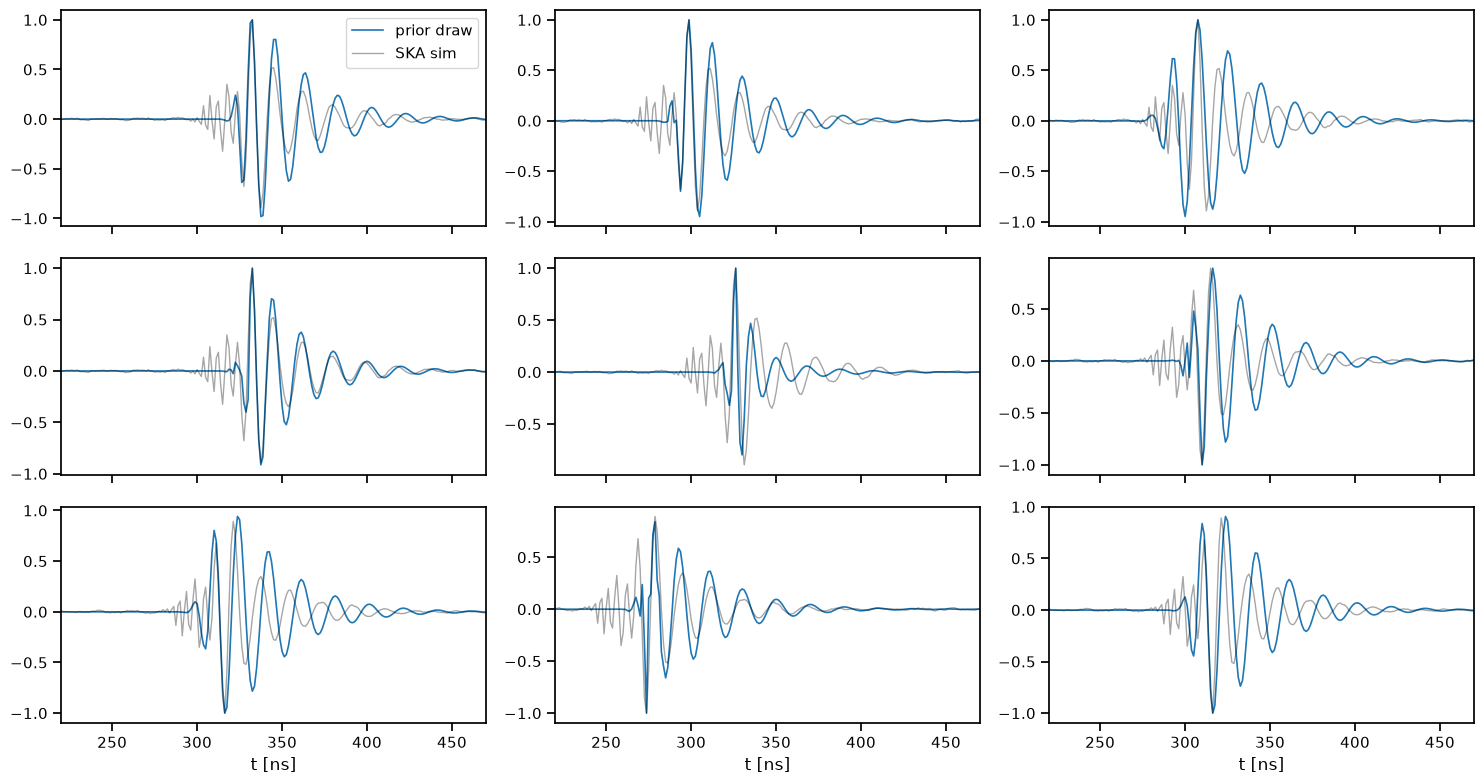

In [8]:
# Sanity check: prior draws vs the simulated SKA pulse + PSNR spread of the prior
tr_ska = np.load("../SKA_Cov/results/200K_1000samples_size800/traces.npy")
ref = tr_ska[0::2].mean(axis=0)   # every realisation has the same CoREAS pulse -> averaging removes the noise
t_ref = np.arange(len(ref)) * 1.25

draw = jax.jit(lambda k: my_model(jft.random_like(k, my_model.domain)))
key, sk = random.split(key)
sigs = np.array([draw(k) for k in random.split(sk, 300)])
psnr_prior = np.max(np.abs(sigs), axis=1) / noise_rms
print("PSNR of prior draws (5/16/50/84/95 %):", np.percentile(psnr_prior, [5, 16, 50, 84, 95]).round(2))
print(f"simulated SKA pulse (ch0): PSNR = {np.max(np.abs(ref)) / noise_rms:.1f}")

sns.set_context("notebook")
fig, axes = plt.subplots(3, 3, figsize=(15, 8), sharex=True)
j = np.argmax(np.abs(ref))
for ax, s in zip(axes.flat, sigs):
    i = np.argmax(np.abs(s))
    ax.plot(t800, s / np.abs(s).max(), lw=1.2, label="prior draw")
    ax.plot(t_ref - t_ref[j] + t800[i], ref / np.abs(ref).max() * np.sign(s[i]), c="k", alpha=0.35, lw=1, label="SKA sim")
    ax.set_xlim(220, 470)
axes[0, 0].legend()
for ax in axes[-1]:
    ax.set_xlabel("t [ns]")
plt.tight_layout()
plt.show()

## Generate mock signals

In [9]:
signal_options = []
data_options = []

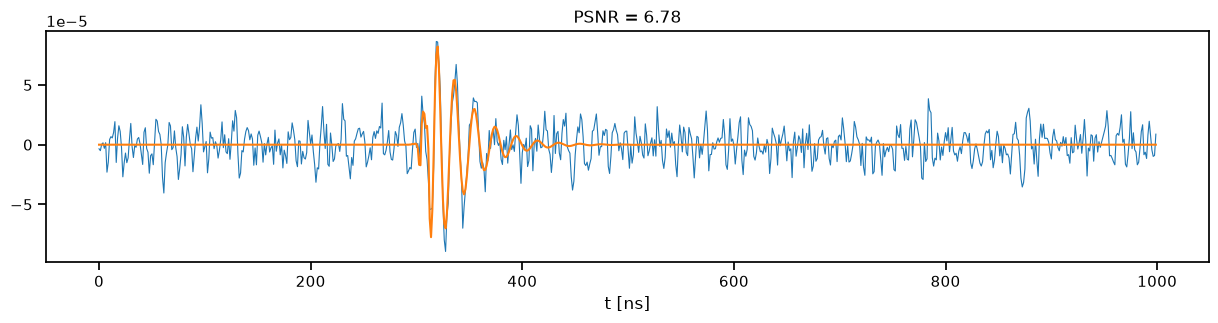

In [10]:
key, k_sig, k_noise = random.split(key, 3)
mock_signal = my_model(jft.random_like(k_sig, my_model.domain))

target_psnr = None   # e.g. 5. -> keep the drawn shape but rescale it to exactly this PSNR
if target_psnr is not None:
    mock_signal = mock_signal * target_psnr * noise_rms / jnp.max(jnp.abs(mock_signal))

noise = noise_std(jft.random_like(k_noise, my_model.target))
mock_data = mock_signal + noise

psnr = np.max(np.abs(mock_signal)) / np.sqrt(np.mean(np.square(mock_data[-50:])))
sns.set_context("notebook")
plt.figure(figsize=(15, 3))
plt.plot(t800, mock_data, c="tab:blue", lw=0.8)
plt.plot(t800, mock_signal, c="tab:orange")
plt.xlabel("t [ns]")
plt.title(f"PSNR = {psnr:.2f}")
plt.show()

In [ ]:
signal_options.append(mock_signal)
data_options.append(mock_data)

In [ ]:
# Optional: a controlled PSNR ladder (prior shapes, exact target PSNRs) instead of hand-picking
psnr_targets = [1, 2, 3, 5, 8, 12, 20, 30, 50]
signal_options, data_options = [], []
for p in psnr_targets:
    key, k_sig, k_noise = random.split(key, 3)
    s = my_model(jft.random_like(k_sig, my_model.domain))
    s = s * p * noise_rms / jnp.max(jnp.abs(s))
    signal_options.append(s)
    data_options.append(s + noise_std(jft.random_like(k_noise, my_model.target)))

fig, axes = plt.subplots(len(psnr_targets), 1, figsize=(15, 1.6 * len(psnr_targets)), sharex=True)
for ax, s, dd, p in zip(axes, signal_options, data_options, psnr_targets):
    ax.plot(t800, dd, c="lightgray")
    ax.plot(t800, s, c="tab:orange")
    ax.set_ylabel(f"PSNR {p}")
axes[-1].set_xlabel("t [ns]")
plt.show()

In [ ]:
plt.figure(figsize=(15, 3))
for signal in signal_options:
    plt.plot(t800, signal)
plt.xlabel("t [ns]")
plt.show()

In [ ]:
# separate file names so the LOFAR mocks (mock_signal1.npy / mock_data1.npy) are not overwritten
np.save("data/mock_signal_ska.npy", np.array(signal_options))
np.save("data/mock_data_ska.npy", np.array(data_options))